#🌿 Plant Disease Detection using Deep Learning

## 1. Environment Setup

In [ ]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
# !pip install tensorflow
# !pip install keras-preprocessing
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile

zip_path = "/content/drive/MyDrive/Colab Notebooks/archive (2).zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


## Dataset Information

In [4]:
import os

dataset_path = "/content/dataset/PlantVillage/train"
# total classes
print("Total classes available:")
classes = os.listdir(dataset_path)
for i, class_name in enumerate(sorted(classes), 1):
    print(f"{i}. {class_name}")

print(f"\nTotal: {len(classes)} classes")

Total classes available:
1. Apple___Apple_scab
2. Apple___Black_rot
3. Apple___Cedar_apple_rust
4. Apple___healthy
5. Blueberry___healthy
6. Cherry_(including_sour)___Powdery_mildew
7. Cherry_(including_sour)___healthy
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_

## Create Custom Dataset (8 Selected Classes)

In [5]:
import shutil

shutil.rmtree("/content/crop_dataset", ignore_errors=True)

print("✅ Old crop_dataset deleted")

✅ Old crop_dataset deleted


In [6]:
import os
import shutil

# Source path
source_train = "/content/dataset/PlantVillage/train"
source_val = "/content/dataset/PlantVillage/val"

# Our 8 classes
selected_classes = [
    "Apple___Apple_scab",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Late_blight",
    "Tomato___Early_blight",
    "Apple___healthy",
    "Corn_(maize)___healthy",
    "Potato___healthy",
    "Tomato___healthy"
]

# new folder
new_base = "/content/crop_dataset"
os.makedirs(new_base, exist_ok=True)

# copy each class
for class_name in selected_classes:
    # Train folder
    src_train = os.path.join(source_train, class_name)
    dst_train = os.path.join(new_base, "train", class_name)

    if os.path.exists(src_train):
        shutil.copytree(src_train, dst_train)
        count = len(os.listdir(src_train))
        print(f"✅ {class_name} - {count} images copied to train")
    else:
        print(f"❌ {class_name} - NOT FOUND in train")


    # Validation folder
    src_val = os.path.join(source_val, class_name)
    dst_val = os.path.join(new_base, "val", class_name)

    if os.path.exists(src_val):
        shutil.copytree(src_val, dst_val)
        count = len(os.listdir(src_val))
        print(f"✅ {class_name} - {count} images copied to val")
    else:
        print(f"❌ {class_name} - NOT FOUND in val")

print("\n✅ Done! 8 classes copied.")

✅ Apple___Apple_scab - 504 images copied to train
✅ Apple___Apple_scab - 126 images copied to val
✅ Corn_(maize)___Northern_Leaf_Blight - 788 images copied to train
✅ Corn_(maize)___Northern_Leaf_Blight - 197 images copied to val
✅ Potato___Late_blight - 800 images copied to train
✅ Potato___Late_blight - 200 images copied to val
✅ Tomato___Early_blight - 800 images copied to train
✅ Tomato___Early_blight - 200 images copied to val
✅ Apple___healthy - 1316 images copied to train
✅ Apple___healthy - 329 images copied to val
✅ Corn_(maize)___healthy - 929 images copied to train
✅ Corn_(maize)___healthy - 233 images copied to val
✅ Potato___healthy - 121 images copied to train
✅ Potato___healthy - 31 images copied to val
✅ Tomato___healthy - 1273 images copied to train
✅ Tomato___healthy - 318 images copied to val

✅ Done! 8 classes copied.


## Dataset Summary

In [7]:
import os

#new dataset
dataset_path = "/content/crop_dataset/train"

# Count
total_images = 0
print("=== DATASET SUMMARY ===\n")

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        total_images += count
        print(f"{class_name}: {count} images")

print(f"\n✅ Total Images: {total_images}")
print(f"✅ Total Classes: {len(os.listdir(dataset_path))}")

=== DATASET SUMMARY ===

Apple___Apple_scab: 504 images
Apple___healthy: 1316 images
Corn_(maize)___Northern_Leaf_Blight: 788 images
Corn_(maize)___healthy: 929 images
Potato___Late_blight: 800 images
Potato___healthy: 121 images
Tomato___Early_blight: 800 images
Tomato___healthy: 1273 images

✅ Total Images: 6531
✅ Total Classes: 8


## Data Loading & Augmentation

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths
train_dir = "/content/crop_dataset/train"

# Image size
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

#  Data Augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values (0-1)
    rotation_range=20,        # Random rotation (0-20 degrees)
    width_shift_range=0.2,    # Horizontal shift
    height_shift_range=0.2,   # Vertical shift
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Random horizontal flip
    fill_mode='nearest'       # Fill missing pixels
)

# Training data load
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

print("✅ Training data ready!")
print(f"Total batches: {len(train_generator)}")
print(f"Images per batch: {BATCH_SIZE}")

Found 6531 images belonging to 8 classes.
✅ Training data ready!
Total batches: 205
Images per batch: 32


## Build Deep Learning Model (Transfer Learning with MobileNetV2)

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# MobileNetV2 load (pre-trained on ImageNet)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,          # Last layer not req
    weights='imagenet'          # Pre-trained weights
)

# freeze base model (no training)
base_model.trainable = False

# buliding custom model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),  # use in place of Flatten
    layers.Dropout(0.5),              # Overfitting avoid
    layers.Dense(128, activation='relu'),
    layers.Dense(8, activation='softmax')  # 8 classes
])

# Model compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

/tmp/ipykernel_1838/2450992353.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# Validation Data Generator

val_dir = "/content/crop_dataset/val"

val_datagen = ImageDataGenerator(
    rescale=1./255
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1634 images belonging to 8 classes.


## Model Training

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define callbacks for better training control
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,           # Stop if no improvement for 5 epochs
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # Reduce learning rate by half
        patience=3,
        min_lr=1e-7
    )
]

# Start training
print("Training starting... ⏳")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Training starting... ⏳
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 93s 364ms/step - accuracy: 0.8146 - loss: 0.5542 - val_accuracy: 0.9357 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 226ms/step - accuracy: 0.9009 - loss: 0.2866 - val_accuracy: 0.9419 - val_loss: 0.1675 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 222ms/step - accuracy: 0.9072 - loss: 0.2632 - val_accuracy: 0.9584 - val_loss: 0.1184 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 222ms/step - accuracy: 0.9228 - loss: 0.2207 - val_accuracy: 0.9590 - val_loss: 0.1434 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 224ms/step - accuracy: 0.9260 - loss: 0.2163 - val_accuracy: 0.9676 - val_loss: 0.1004 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 49s 239ms/step - accuracy: 0.9290 - loss: 0.2058 - val_accuracy: 0.9651 - val_loss: 0.1015 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 46s 225

## Experiment 2 - Training for Full 20 Epochs

#1.Fresh Model Build

#2.Model Training (20 Epochs)

In [11]:
# ==========================
# Build Fresh Model
# ==========================

import tensorflow as tf
from tensorflow.keras import layers, models

# Load MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(150, 150, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers
base_model.trainable = False

# Build model
model_exp2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dense(8, activation="softmax")
])

# Compile model
model_exp2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Fresh model created successfully!")
model_exp2.summary()

/tmp/ipykernel_1838/2637297926.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


✅ Fresh model created successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,984 (9.24 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Callback
callbacks_exp2 = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
]

print("🚀 Experiment 2 Training Started...")

history_exp2 = model_exp2.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks_exp2,
    verbose=1
)

print("\n✅ Experiment 2 Training Completed!")

🚀 Experiment 2 Training Started...
Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 101s 395ms/step - accuracy: 0.8284 - loss: 0.5067 - val_accuracy: 0.9486 - val_loss: 0.1581 - learning_rate: 0.0010
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 47s 230ms/step - accuracy: 0.9048 - loss: 0.2793 - val_accuracy: 0.9596 - val_loss: 0.1063 - learning_rate: 0.0010
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 48s 234ms/step - accuracy: 0.9156 - loss: 0.2522 - val_accuracy: 0.9492 - val_loss: 0.1230 - learning_rate: 0.0010
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 81s 231ms/step - accuracy: 0.9198 - loss: 0.2326 - val_accuracy: 0.9682 - val_loss: 0.0834 - learning_rate: 0.0010
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 48s 234ms/step - accuracy: 0.9207 - loss: 0.2151 - val_accuracy: 0.9682 - val_loss: 0.0956 - learning_rate: 0.0010
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 47s 227ms/step - accuracy: 0.9294 - loss: 0.2064 - val_accuracy: 0.9498 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━

## Save Final Model

In [13]:
model_exp2.save("/content/best_crop_model.keras")
print("✅ Model saved successfully!")

✅ Model saved successfully!


## Training Performance Visualization

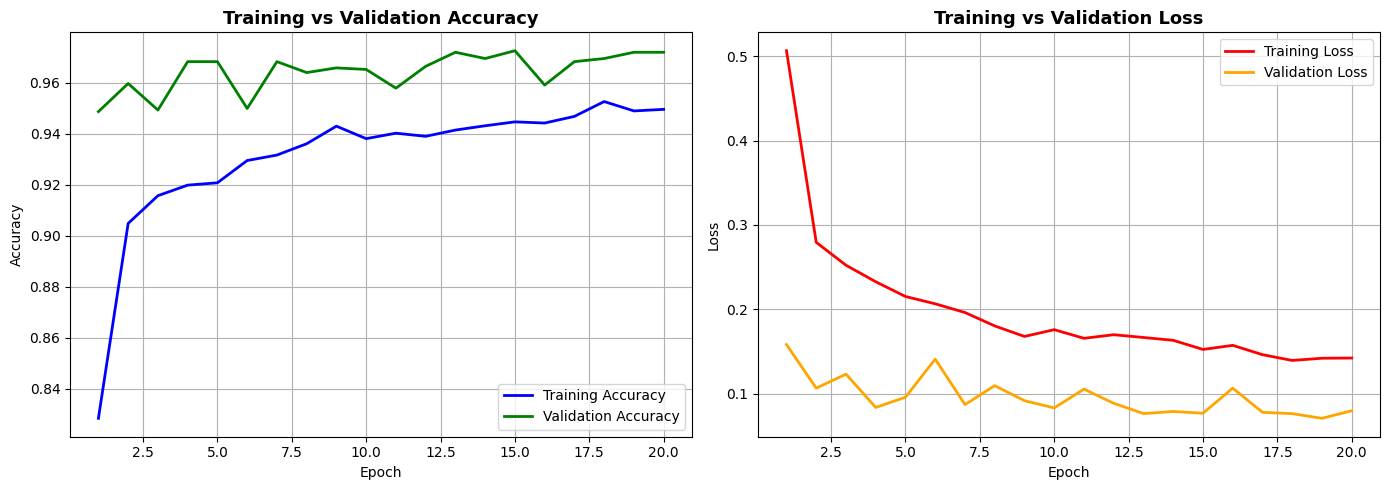

✅ Final Training Accuracy   : 94.95%
✅ Final Validation Accuracy : 97.18%
✅ Final Training Loss       : 0.1421
✅ Final Validation Loss     : 0.0795


In [14]:
import matplotlib.pyplot as plt

# Experiment 2 History
acc = history_exp2.history['accuracy']
val_acc = history_exp2.history['val_accuracy']

loss = history_exp2.history['loss']
val_loss = history_exp2.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', linewidth=2, label='Training Accuracy')
plt.plot(epochs, val_acc, 'g-', linewidth=2, label='Validation Accuracy')
plt.title("Training vs Validation Accuracy", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss Graph
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'r-', linewidth=2, label='Training Loss')
plt.plot(epochs, val_loss, 'orange', linewidth=2, label='Validation Loss')
plt.title("Training vs Validation Loss", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("="*50)
print(f"✅ Final Training Accuracy   : {acc[-1]*100:.2f}%")
print(f"✅ Final Validation Accuracy : {val_acc[-1]*100:.2f}%")
print(f"✅ Final Training Loss       : {loss[-1]:.4f}")
print(f"✅ Final Validation Loss     : {val_loss[-1]:.4f}")
print("="*50)

## Disease Prediction on Sample Validation Image

Classes: ['Apple___Apple_scab', 'Apple___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Early_blight', 'Tomato___healthy']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


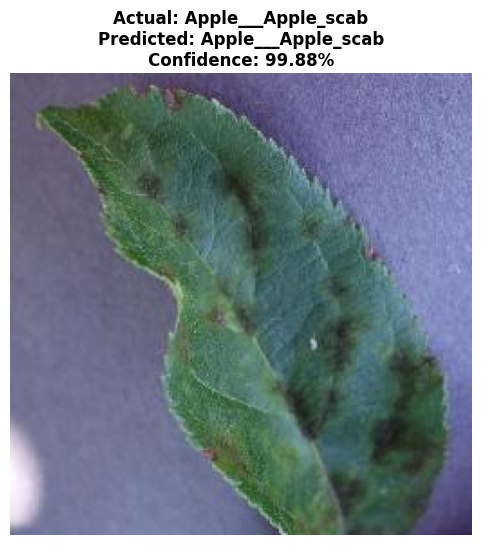

Predicted Class: Apple___Apple_scab
Confidence: 99.88%
Actual Class: Apple___Apple_scab


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# Class names
class_names = list(train_generator.class_indices.keys())
print("Classes:", class_names)

# Test images  folder from(val folder)
test_dir = "/content/crop_dataset/val"

# pick random image
test_class = "Apple___Apple_scab"
test_images = os.listdir(os.path.join(test_dir, test_class))
img_path = os.path.join(test_dir, test_class, test_images[0])

# Image load
img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Prediction
prediction = model_exp2.predict(img_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

# Result
plt.figure(figsize=(6, 6))
plt.imshow(image.load_img(img_path))
plt.title(
    f"Actual: {test_class}\nPredicted: {predicted_class}\nConfidence: {confidence:.2f}%",
    fontsize=12,
    fontweight='bold'
)
plt.axis('off')
plt.show()

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")
print(f"Actual Class: {test_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted: Apple___Apple_scab


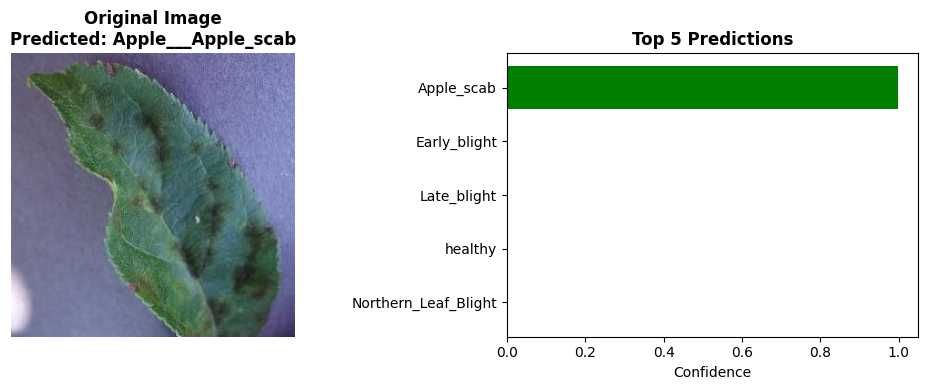

✅ Visualization complete!


In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

# 1. Load test image
test_class = "Apple___Apple_scab"
test_dir = "/content/crop_dataset/val"
img_path = os.path.join(test_dir, test_class, os.listdir(os.path.join(test_dir, test_class))[0])

img = image.load_img(img_path, target_size=(150, 150))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# 2. Prediction
prediction = model_exp2.predict(img_array)
predicted_class = list(train_generator.class_indices.keys())[np.argmax(prediction)]
print(f"Predicted: {predicted_class}")

# 3. Simple Visualization (Model  predictions )
plt.figure(figsize=(10, 4))

# Original Image
plt.subplot(1, 2, 1)
plt.imshow(image.load_img(img_path))
plt.title(f"Original Image\nPredicted: {predicted_class}", fontweight='bold')
plt.axis('off')

# Confidence Bar Chart
plt.subplot(1, 2, 2)
class_names = list(train_generator.class_indices.keys())
confidences = prediction[0]
top_5_idx = np.argsort(confidences)[-5:][::-1]

colors = ['green' if class_names[i] == predicted_class else 'gray' for i in top_5_idx]
plt.barh(range(5), confidences[top_5_idx], color=colors)
plt.yticks(range(5), [class_names[i].split('___')[1] if '___' in class_names[i] else class_names[i] for i in top_5_idx])
plt.xlabel('Confidence')
plt.title('Top 5 Predictions', fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

## Disease Treatment & Prevention Recommendation

In [19]:
# Treatment Dictionary
treatment_dict = {
    "Apple___Apple_scab": "✅ Treatment: Apply fungicide spray (Captan or Mancozeb). \n🌱 Prevention: Clean fallen leaves, perform pruning.",
    "Apple___healthy": "✅ No treatment needed! \n🌱 Continue regular monitoring.",
    "Corn_(maize)___Northern_Leaf_Blight": "✅ Treatment: Apply fungicide (Azoxystrobin). \n🌱 Prevention: Use resistant varieties.",
    "Corn_(maize)___healthy": "✅ No treatment needed! \n🌱 Continue regular monitoring.",
    "Potato___Late_blight": "✅ Treatment: Apply fungicide (Metalaxyl + Mancozeb). \n🌱 Prevention: Maintain proper drainage.",
    "Potato___healthy": "✅ No treatment needed! \n🌱 Continue regular monitoring.",
    "Tomato___Early_blight": "✅ Treatment: Apply fungicide (Chlorothalonil). \n🌱 Prevention: Remove lower leaves.",
    "Tomato___healthy": "✅ No treatment needed! \n🌱 Continue regular monitoring."
}

print("📚 Treatment Dictionary Created!")
print("="*60)

# Testing the dictionary
predicted_disease = predicted_class  # From previous prediction
treatment = treatment_dict.get(predicted_disease, "Treatment information not available")

print(f"🩺 Disease Detected : {predicted_disease}")
print(f"🎯 Confidence Score : {confidence:.2f}%")
print("="*60)
print(treatment)
print("="*60)

📚 Treatment Dictionary Created!
🩺 Disease Detected : Apple___Apple_scab
🎯 Confidence Score : 99.88%
✅ Treatment: Apply fungicide spray (Captan or Mancozeb). 
🌱 Prevention: Clean fallen leaves, perform pruning.


## Model Evaluation

52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 123ms/step


<Figure size 1000x1000 with 0 Axes>

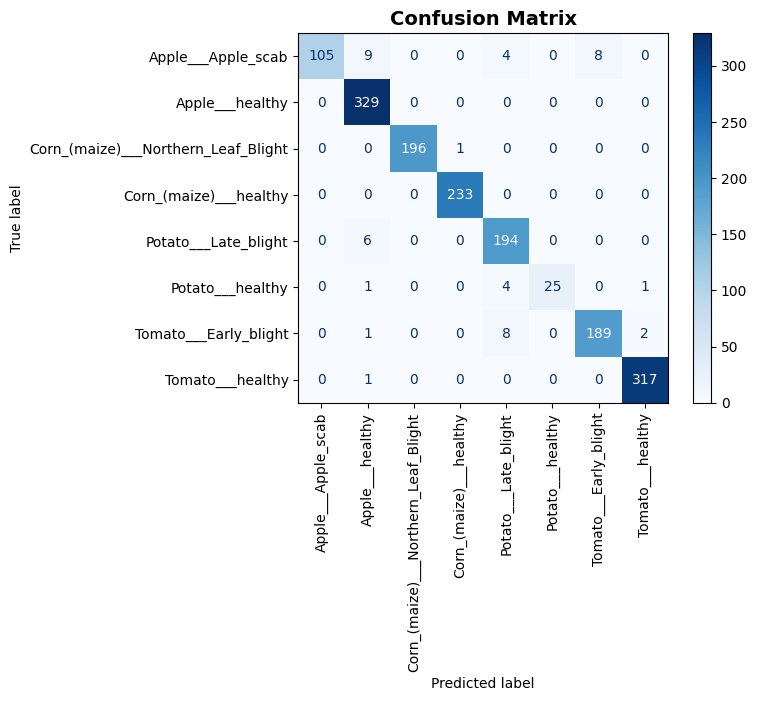

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Reset validation generator
val_generator.reset()

# Predict on validation dataset
y_pred = model_exp2.predict(val_generator, verbose=1)

# Predicted labels
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = val_generator.classes

# Class names
class_names = list(val_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=90)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.show()

In [21]:
from sklearn.metrics import classification_report

# Generate Classification Report
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print("="*70)
print("Classification Report")
print("="*70)
print(report)

Classification Report
                                     precision    recall  f1-score   support

                 Apple___Apple_scab       1.00      0.83      0.91       126
                    Apple___healthy       0.95      1.00      0.97       329
Corn_(maize)___Northern_Leaf_Blight       1.00      0.99      1.00       197
             Corn_(maize)___healthy       1.00      1.00      1.00       233
               Potato___Late_blight       0.92      0.97      0.95       200
                   Potato___healthy       1.00      0.81      0.89        31
              Tomato___Early_blight       0.96      0.94      0.95       200
                   Tomato___healthy       0.99      1.00      0.99       318

                           accuracy                           0.97      1634
                          macro avg       0.98      0.94      0.96      1634
                       weighted avg       0.97      0.97      0.97      1634



In [23]:
from google.colab import files
import os

file_path = "/content/best_crop_model.keras"

if os.path.exists(file_path):
    files.download(file_path)
    print("✅ Model downloaded successfully!")
else:
    print("❌ Model file not found. Please run the Save Model cell first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded successfully!
